# Ingredient CO₂e Matching — Visualizations

**Pipeline overview:**
1. `recipe_ingredients.csv` holds raw ingredient names with free-text quantities.
2. `main.ipynb` tries to match every unique ingredient to a CO₂e value:
   - **Wolfram (direct)** — ingredient name is already in the Wolfram Alpha food carbon dataset.
   - **Wolfram (manual alias)** — a hand-crafted map translates the recipe name → Wolfram clean name.
   - **OWID fallback** — if Wolfram fails, a second map resolves the ingredient to an [Our World In Data](https://ourworldindata.org/) entity.
   - **Unmatched** — no CO₂e value could be assigned.
3. Matched values are saved to `ingredient_co2.csv`.

These charts expose every step: what was matched, how, and what was left out.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10})

COLORS = {
    'Wolfram (direct)':       '#2E86AB',
    'Wolfram (manual alias)': '#A23B72',
    'OWID fallback':          '#F18F01',
    'Unmatched':              '#C73E1D',
}

# ── Load data ──────────────────────────────────────────────────────────────────
ingr_df = pd.read_csv('../preprocessing/recipe_ingredients.csv')
co2_df  = pd.read_csv('../preprocessing/ingredient_co2.csv')

ingr_df['ingredient_lower'] = ingr_df['ingredient_name'].str.lower().str.strip()
co2_lookup = set(co2_df['ingredient'].str.lower().str.strip())

# ── Source maps (from main.ipynb) ──────────────────────────────────────────────
WOLFRAM_MAP = {
    'lentils (dal)':    'lentil',         'mint leaves':      'fresh mint',
    'fresh coriander':  'coriander seed', 'tamarind paste':   'tamarind',
    'sesame seeds':     'sesame',         'coriander':        'coriander seed',
    'green chili':      'chili pepper',   'bell pepper':      'pepper',
    'oil':              'sesame oil',     'cooking oil':      'sesame oil',
    'all-purpose flour':'wheat flour',    'red chili powder': 'chili pepper',
    'garam masala':     'spice',          'black pepper':     'black peppercorn',
    'cloves':           'clove',          'milk':             'milks',
    'water':            'bottled water',  'eggs':             'egg',
    'fenugreek leaves': 'fenugreek seed', 'curry leaves':     'curry powder',
    'chickpeas':        'chickpea',       'fish':             'fishes',
    'mustard seeds':    'mustard',        'almonds':          'almond',
    'cashews':          'cashew',         'raisins':          'raisin',
    'bay leaf':         'herbs',          'peas':             'pea',
    'ghee':             'butter',         'salt':             'sea salt',
}
OWID_MAP = {
    'paneer':'cheese','semolina':'wheat & rye','chicken':'poultry meat',
    'onion':'onions & leeks','milk':'milk','lentils (dal)':'other pulses',
    'chickpeas':'other pulses','peas':'peas','potato':'potatoes',
    'tomato':'tomatoes','carrot':'root vegetables','cauliflower':'brassicas',
    'almonds':'nuts','cashews':'nuts','raisins':'berries & grapes',
    'green chili':'other vegetables','red chili powder':'other vegetables',
    'cloves':'other vegetables','sesame seeds':'groundnuts','tamarind paste':'other fruit',
}

def classify_source(ingr: str) -> str:
    ingr_l = ingr.lower().strip()
    if ingr_l not in co2_lookup:
        return 'Unmatched'
    if ingr_l in WOLFRAM_MAP:
        return 'Wolfram (manual alias)'
    if ingr_l in OWID_MAP:
        return 'OWID fallback'
    return 'Wolfram (direct)'

freq = ingr_df['ingredient_lower'].value_counts().rename('frequency')
source_df = pd.DataFrame([{'ingredient': i, 'source': classify_source(i)}
                           for i in ingr_df['ingredient_lower'].unique()])
source_df = source_df.merge(freq.reset_index().rename(columns={'ingredient_lower':'ingredient'}), on='ingredient', how='left')
co2_vals = co2_df.copy()
co2_vals['ingredient'] = co2_vals['ingredient'].str.lower()
source_df = source_df.merge(co2_vals, on='ingredient', how='left')

print(source_df['source'].value_counts().to_string())
print(f"\nTotal unique ingredients : {len(source_df)}")
print(f"CO₂e coverage           : {(source_df['source'] != 'Unmatched').sum()} / {len(source_df)}")


source
Wolfram (manual alias)    29
Wolfram (direct)          21
OWID fallback              8

Total unique ingredients : 58
CO₂e coverage           : 58 / 58


## 1 · Overall CO₂e Source Breakdown

How many unique ingredient names were resolved from each source, and how much of the total recipe-ingredient usage (row count) each source covers.

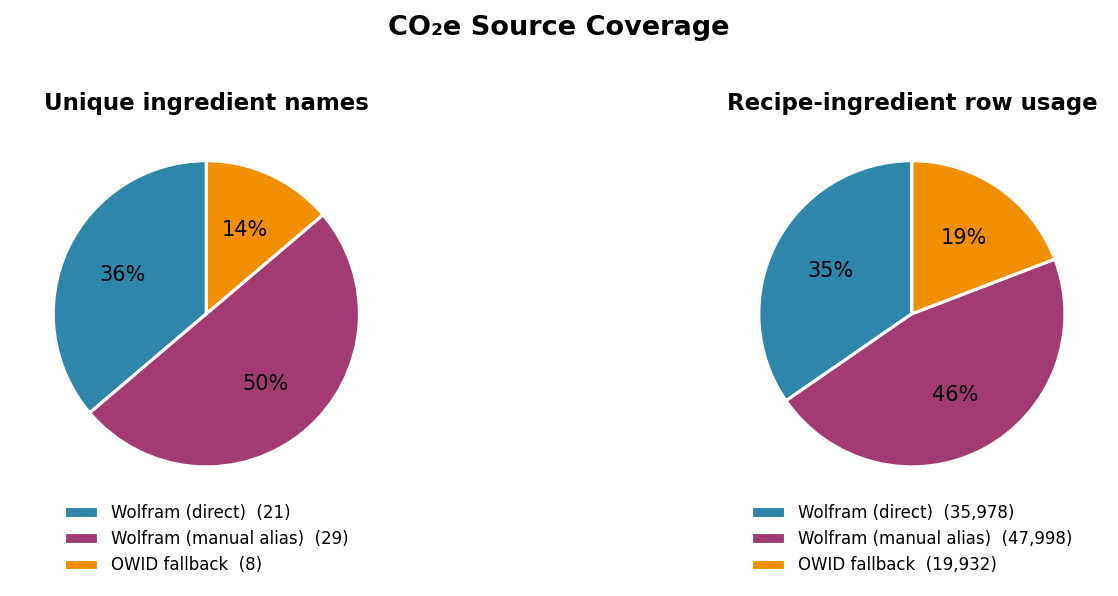

In [3]:
uniq_counts = source_df['source'].value_counts()
usage_map = ingr_df['ingredient_lower'].value_counts()
source_df['usage_count'] = source_df['ingredient'].map(usage_map).fillna(0).astype(int)
usage_counts = source_df.groupby('source')['usage_count'].sum()

labels_order = ['Wolfram (direct)', 'Wolfram (manual alias)', 'OWID fallback', 'Unmatched']
colors = [COLORS[l] for l in labels_order if l in uniq_counts]
labels_present = [l for l in labels_order if l in uniq_counts]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(
    axes,
    [uniq_counts.reindex(labels_present), usage_counts.reindex(labels_present)],
    ['Unique ingredient names', 'Recipe-ingredient row usage'],
):
    wedges, texts, autotexts = ax.pie(
        data.values, labels=None, colors=colors,
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
    )
    ax.set_title(title, fontsize=11, fontweight='bold')
    legend_labels = [f"{l}  ({v:,})" for l, v in zip(data.index, data.values)]
    ax.legend(wedges, legend_labels, loc='lower center',
              bbox_to_anchor=(0.5, -0.22), fontsize=8, frameon=False)

fig.suptitle('CO₂e Source Coverage', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/01_source_coverage.png', bbox_inches='tight')
plt.show()


## 2 · Manual Wolfram Alias Map

The alias map translates colloquial recipe ingredient names to the Wolfram database's clean names. This chart shows every mapping used.

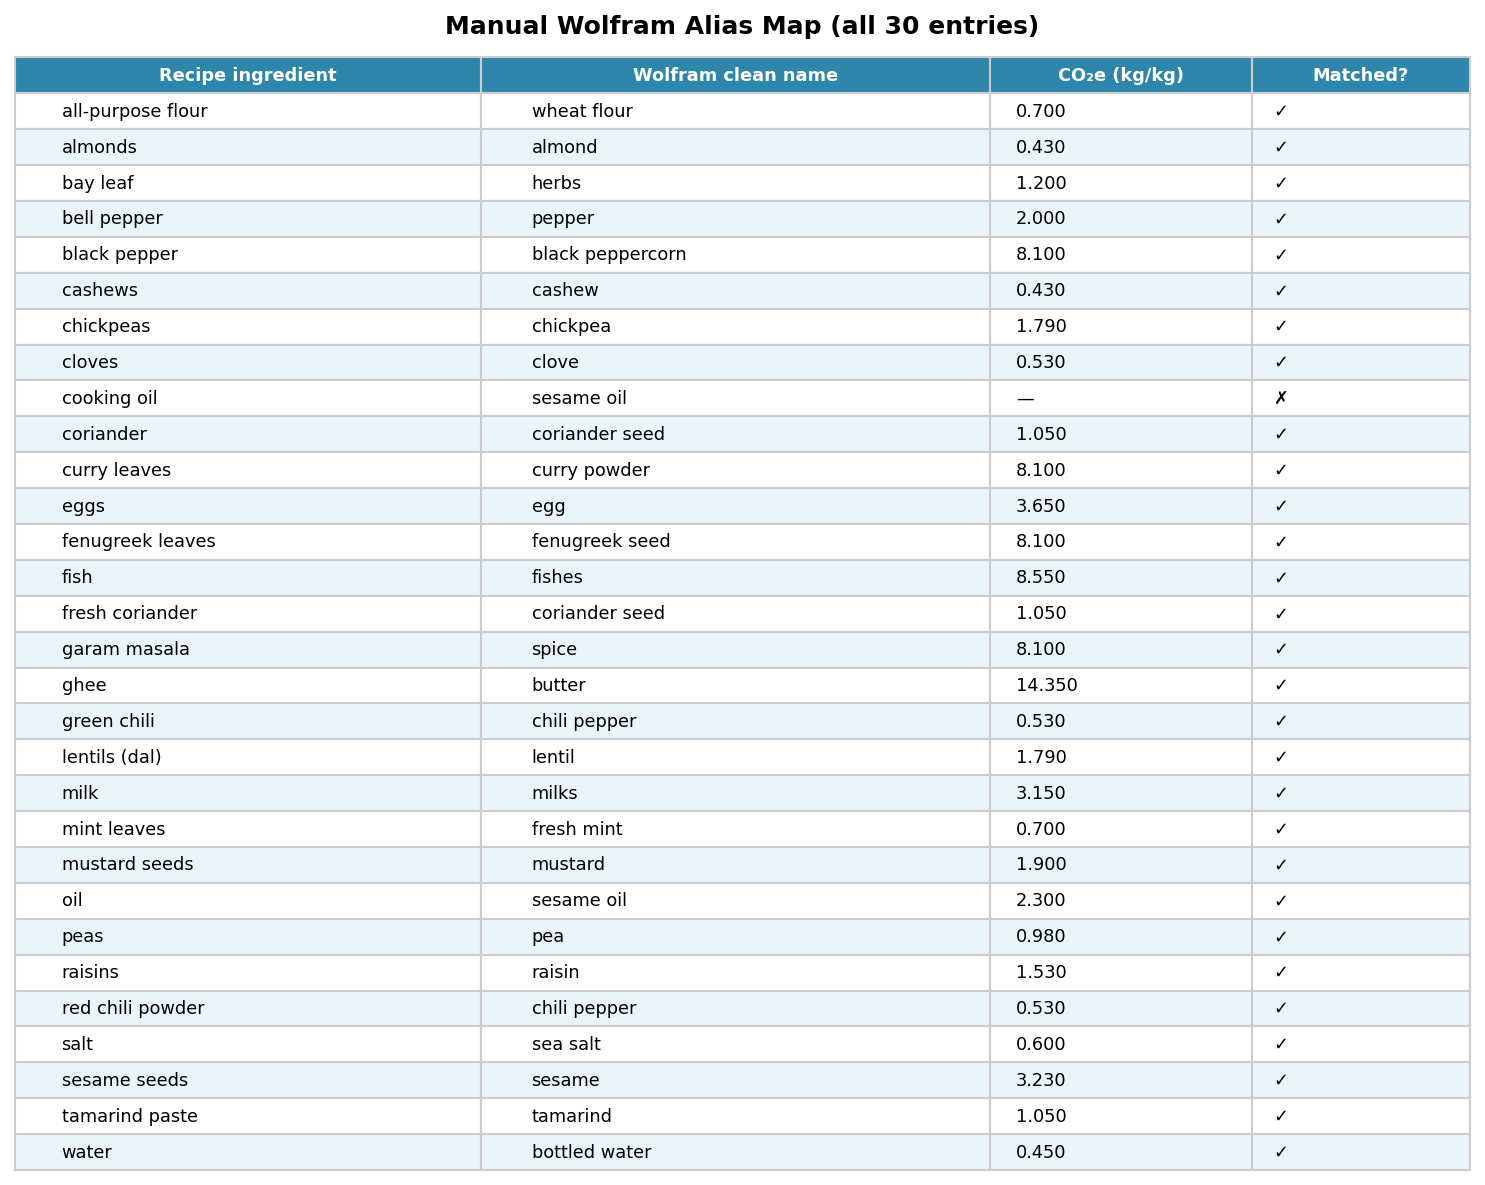

In [4]:
wolfram_alias_df = pd.DataFrame([
    {'Recipe ingredient': k, 'Wolfram clean name': v} for k, v in WOLFRAM_MAP.items()
]).sort_values('Recipe ingredient').reset_index(drop=True)
wolfram_alias_df['CO₂e (kg/kg)'] = wolfram_alias_df['Recipe ingredient'].map(
    source_df.set_index('ingredient')['co2_kg_per_kg']
).apply(lambda x: f"{x:.3f}" if pd.notna(x) else '—')
wolfram_alias_df['Matched?'] = wolfram_alias_df['Recipe ingredient'].apply(
    lambda x: '✓' if x in co2_lookup else '✗'
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
col_widths = [0.32, 0.35, 0.18, 0.15]
tbl = ax.table(
    cellText=wolfram_alias_df.values,
    colLabels=wolfram_alias_df.columns,
    cellLoc='left', loc='center',
    colWidths=col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2E86AB')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EAF4FB')
    cell.set_edgecolor('#CCCCCC')

fig.suptitle('Manual Wolfram Alias Map (all 30 entries)', fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('figures/02_wolfram_alias_map.png', bbox_inches='tight')
plt.show()


## 3 · OWID Fallback Map

For ingredients where Wolfram had no match, a second lookup used the Our World In Data GHG-per-kg dataset. The table below shows every OWID proxy used and how the recipe name maps to an OWID entity.

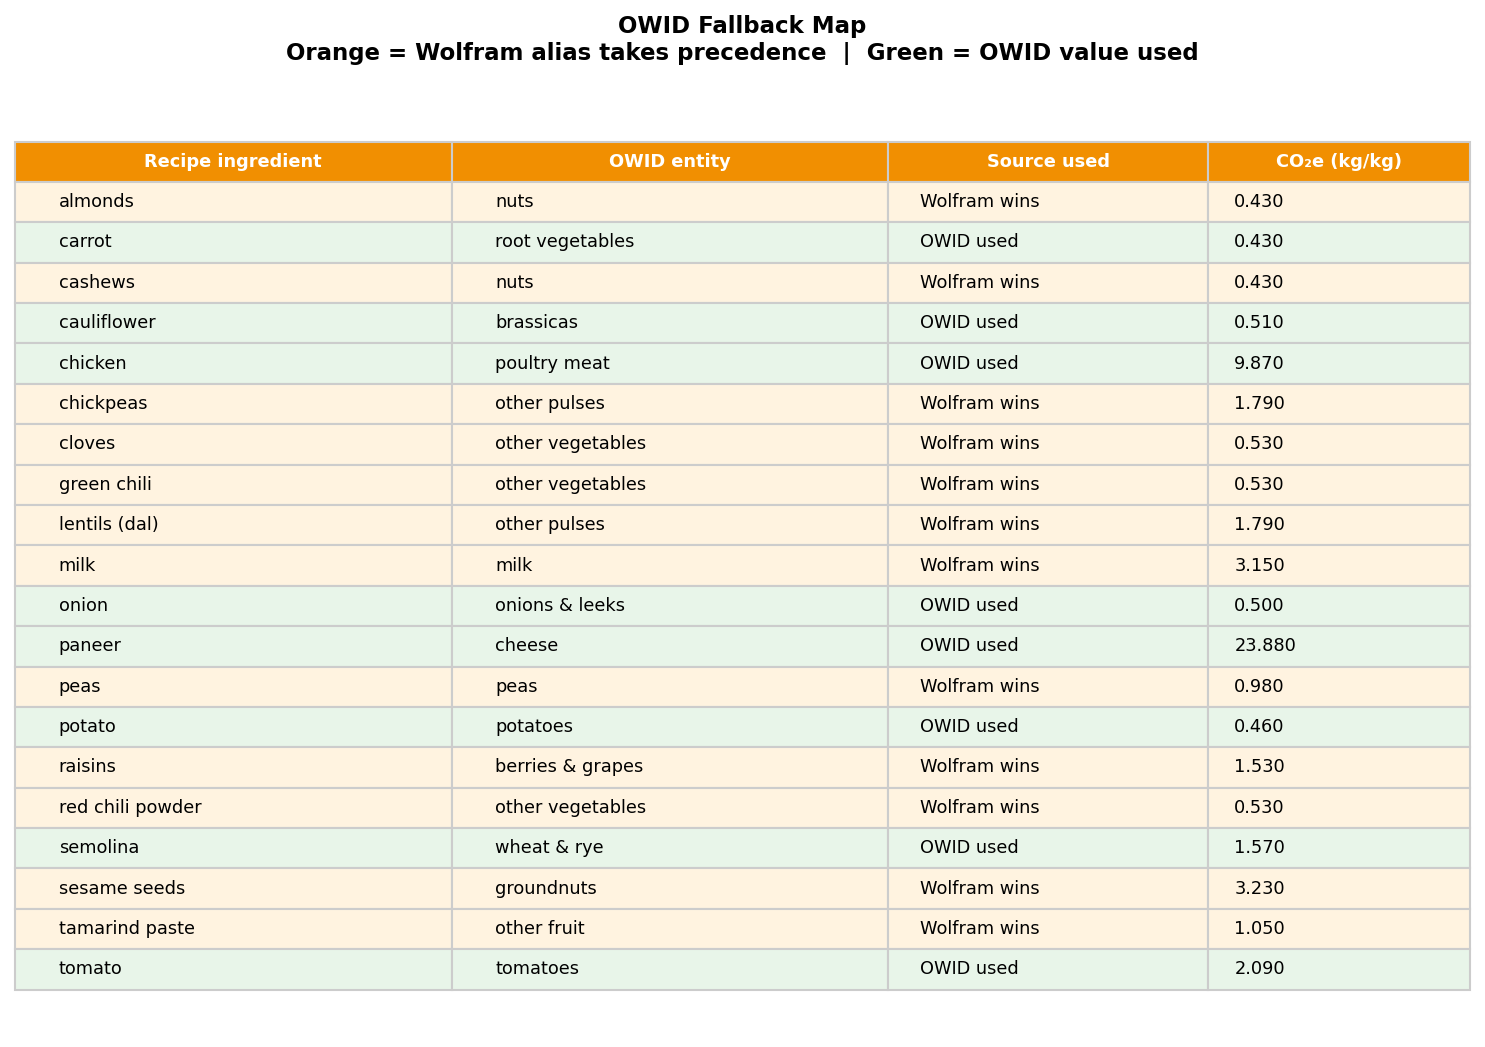

In [5]:
owid_rows = []
for k, v in sorted(OWID_MAP.items()):
    also_wolfram = k in WOLFRAM_MAP
    co2_val = source_df.loc[source_df['ingredient'] == k, 'co2_kg_per_kg']
    co2_str = f"{co2_val.values[0]:.3f}" if len(co2_val) and pd.notna(co2_val.values[0]) else '—'
    owid_rows.append({
        'Recipe ingredient': k,
        'OWID entity': v,
        'Source used': 'Wolfram wins' if also_wolfram else 'OWID used',
        'CO₂e (kg/kg)': co2_str,
    })
owid_tbl = pd.DataFrame(owid_rows)

fig, ax = plt.subplots(figsize=(10, 7))
ax.axis('off')
tbl = ax.table(
    cellText=owid_tbl.values,
    colLabels=owid_tbl.columns,
    cellLoc='left', loc='center',
    colWidths=[0.30, 0.30, 0.22, 0.18],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.4)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#F18F01')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        src = owid_tbl.iloc[row - 1]['Source used'] if row <= len(owid_tbl) else ''
        cell.set_facecolor('#FFF3E0' if src == 'Wolfram wins' else '#E8F5E9')
    cell.set_edgecolor('#CCCCCC')

fig.suptitle('OWID Fallback Map\nOrange = Wolfram alias takes precedence  |  Green = OWID value used',
             fontsize=11, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('figures/03_owid_fallback_map.png', bbox_inches='tight')
plt.show()


## 4 · All Ingredient CO₂e Values — Coloured by Source

Every ingredient that received a CO₂e value, sorted descending. Bar colour encodes data source.

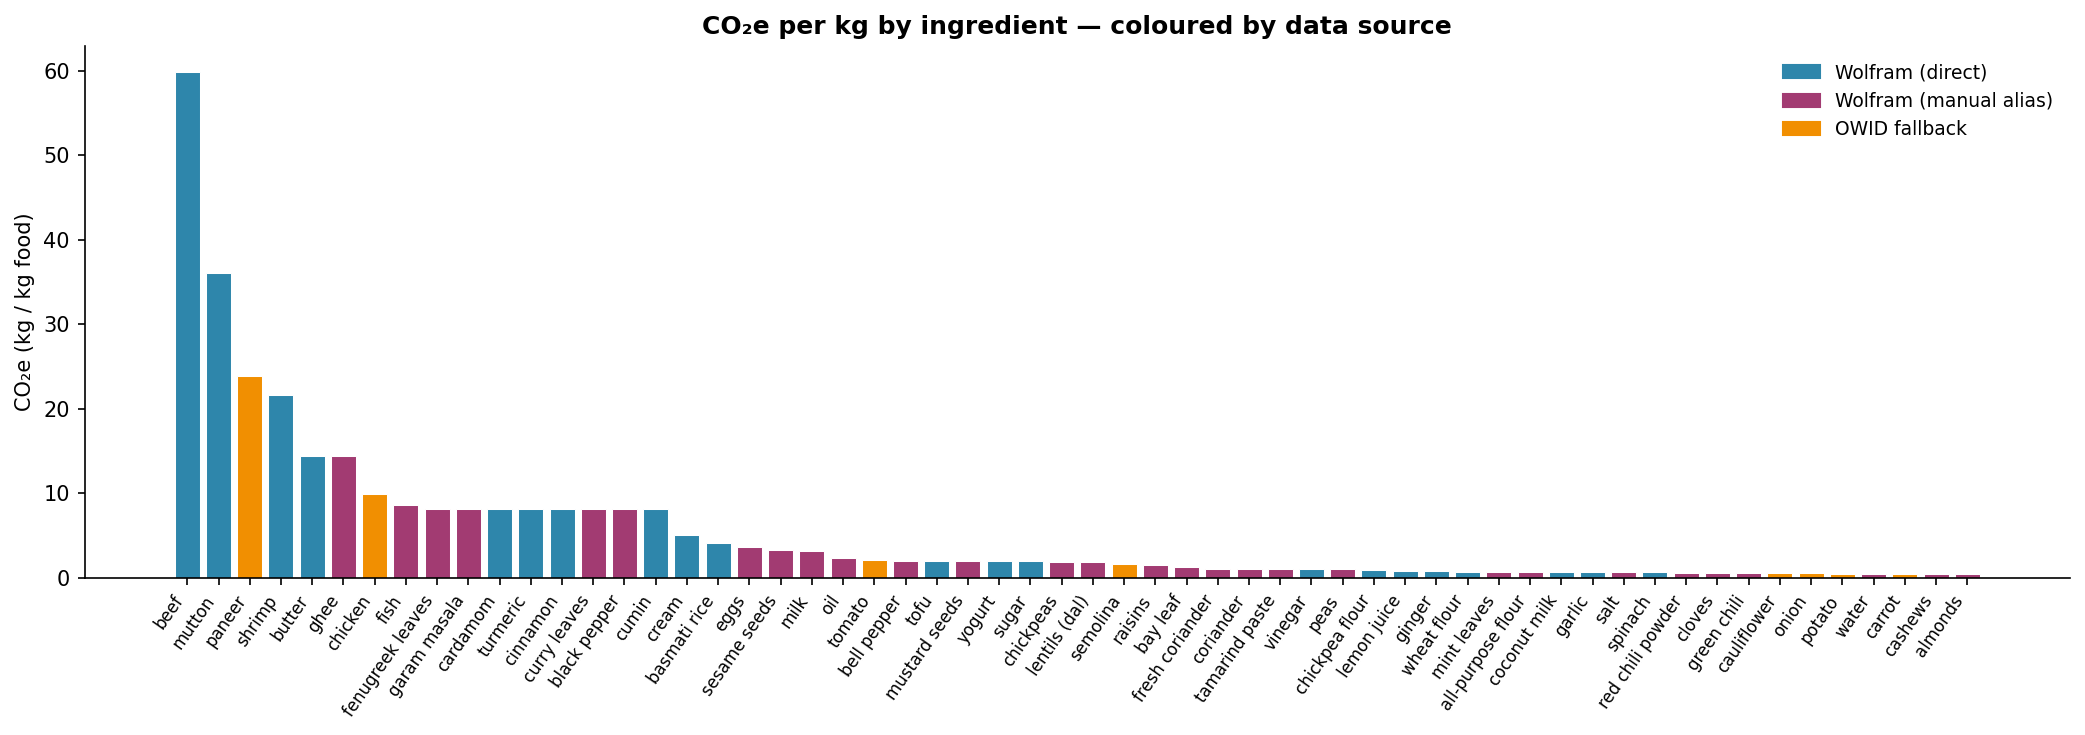

In [6]:
matched_df = source_df[source_df['source'] != 'Unmatched'].sort_values('co2_kg_per_kg', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [COLORS[s] for s in matched_df['source']]
bars = ax.bar(range(len(matched_df)), matched_df['co2_kg_per_kg'], color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(matched_df)))
ax.set_xticklabels(matched_df['ingredient'], rotation=55, ha='right', fontsize=8)
ax.set_ylabel('CO₂e (kg / kg food)')
ax.set_title('CO₂e per kg by ingredient — coloured by data source', fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [mpatches.Patch(color=COLORS[s], label=s)
                  for s in ['Wolfram (direct)', 'Wolfram (manual alias)', 'OWID fallback']]
ax.legend(handles=legend_handles, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('figures/04_ingredient_co2_by_source.png', bbox_inches='tight')
plt.show()


## 5 · Coverage Impact of Each Matching Layer

Without manual maps the majority of ingredients would have no CO₂e value. This chart shows the cumulative coverage gain — in unique ingredient names and in recipe-ingredient rows — as each layer is added.

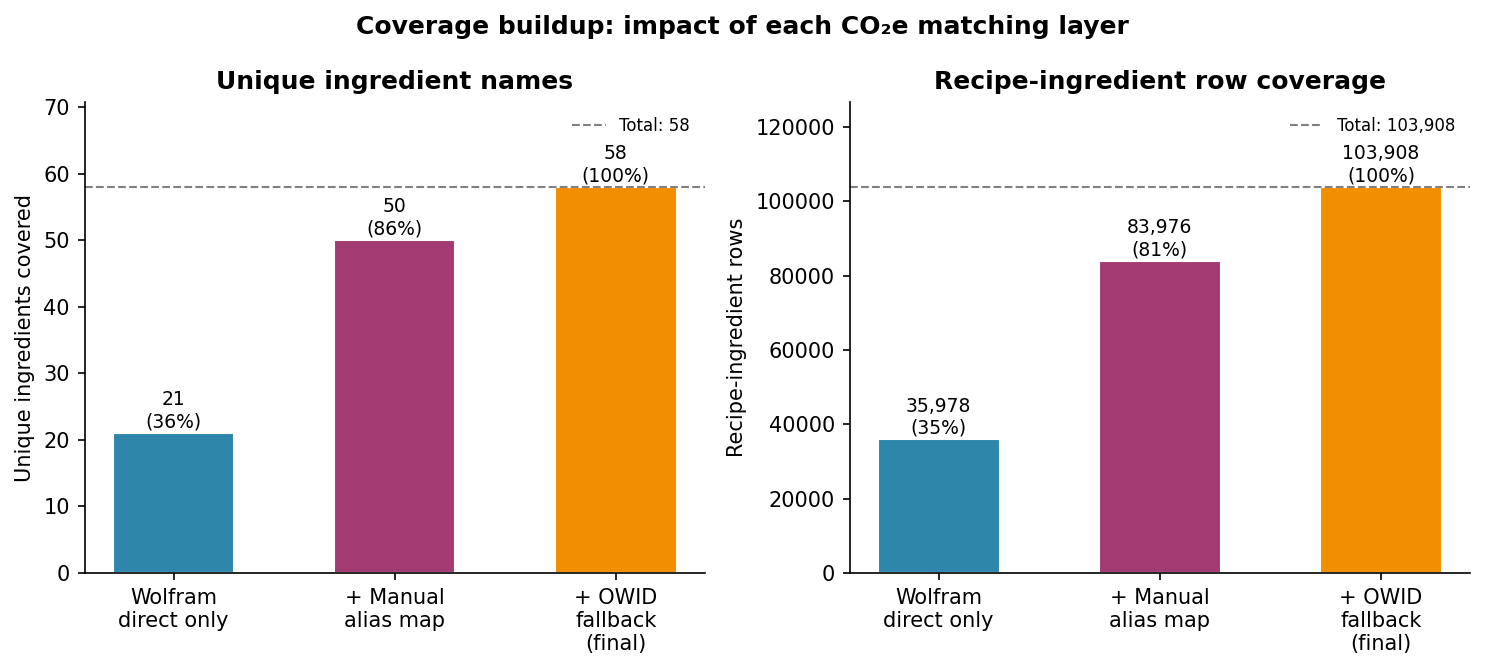

In [11]:

direct_ingrs = set(source_df.loc[source_df['source'] == 'Wolfram (direct)', 'ingredient'])
alias_ingrs  = set(source_df.loc[source_df['source'] == 'Wolfram (manual alias)', 'ingredient'])
owid_ingrs   = set(source_df.loc[source_df['source'] == 'OWID fallback', 'ingredient'])

freq_map = ingr_df['ingredient_lower'].value_counts()

def rows_for(ingr_set):
    return int(freq_map[freq_map.index.isin(ingr_set)].sum())

total_ingrs = len(source_df)
total_rows  = len(ingr_df)

scenarios = [
    ('Wolfram\ndirect only',         direct_ingrs,                             ),
    ('+ Manual\nalias map',          direct_ingrs | alias_ingrs,               ),
    ('+ OWID\nfallback\n(final)',    direct_ingrs | alias_ingrs | owid_ingrs,  ),
]

bar_colors = ['#2E86AB', '#A23B72', '#F18F01']

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (get_val, ylabel, title) in zip(
    axes,
    [
        (lambda s: len(s),      'Unique ingredients covered', 'Unique ingredient names'),
        (lambda s: rows_for(s), 'Recipe-ingredient rows',     'Recipe-ingredient row coverage'),
    ],
):
    vals  = [get_val(s[1]) for s in scenarios]
    total = total_ingrs if 'names' in title else total_rows
    labels_x = [s[0] for s in scenarios]
    bars = ax.bar(labels_x, vals, color=bar_colors, edgecolor='white', width=0.55)
    ax.axhline(total, color='grey', linestyle='--', linewidth=1, label=f'Total: {total:,}')
    for bar, val in zip(bars, vals):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.015,
                f'{val:,}\n({pct:.0f}%)', ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, total * 1.22)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Coverage buildup: impact of each CO₂e matching layer', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_coverage_buildup.png', bbox_inches='tight')
plt.show()


## 6 · Ingredient CO₂e Footprint vs Recipe Frequency

Each bubble is one ingredient. X = its CO₂e emission factor (kg CO₂e per kg food), Y = how many times it appears across all recipes. Size and colour encode the same two dimensions for readability. High-impact ingredients in the top-right corner drive the most total emissions.

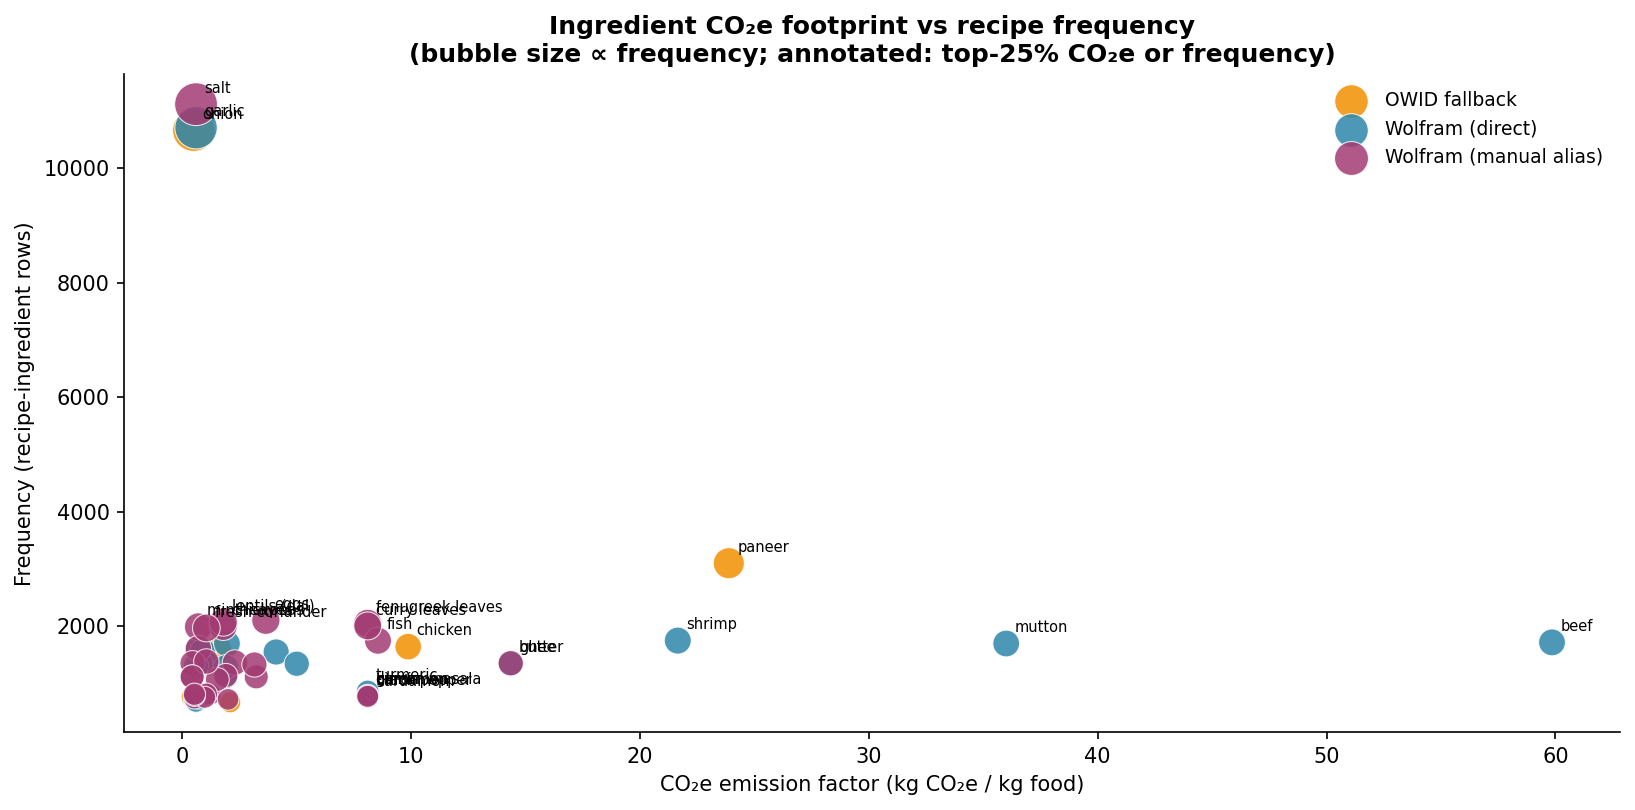

In [13]:

matched = source_df[source_df['source'] != 'Unmatched'].dropna(subset=['co2_kg_per_kg']).copy()

fig, ax = plt.subplots(figsize=(11, 5.5))
for src, grp in matched.groupby('source'):
    sizes = grp['frequency'].clip(lower=1).pow(0.5) * 4
    ax.scatter(grp['co2_kg_per_kg'], grp['frequency'],
               color=COLORS[src], label=src,
               s=sizes, alpha=0.85, edgecolors='white', linewidth=0.5)

threshold_co2  = matched['co2_kg_per_kg'].quantile(0.75)
threshold_freq = matched['frequency'].quantile(0.75)
for _, row in matched.iterrows():
    if row['co2_kg_per_kg'] >= threshold_co2 or row['frequency'] >= threshold_freq:
        ax.annotate(row['ingredient'],
                    (row['co2_kg_per_kg'], row['frequency']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('CO₂e emission factor (kg CO₂e / kg food)')
ax.set_ylabel('Frequency (recipe-ingredient rows)')
ax.set_title('Ingredient CO₂e footprint vs recipe frequency\n'
             '(bubble size ∝ frequency; annotated: top-25% CO₂e or frequency)',
             fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/06_co2_vs_frequency.png', bbox_inches='tight')
plt.show()


## 7 · Source Mix per Recipe (Stacked Bar, Sample)

For each recipe, how many ingredients came from Wolfram (direct / alias) vs OWID vs are unmatched. Sorted by total ingredient count.

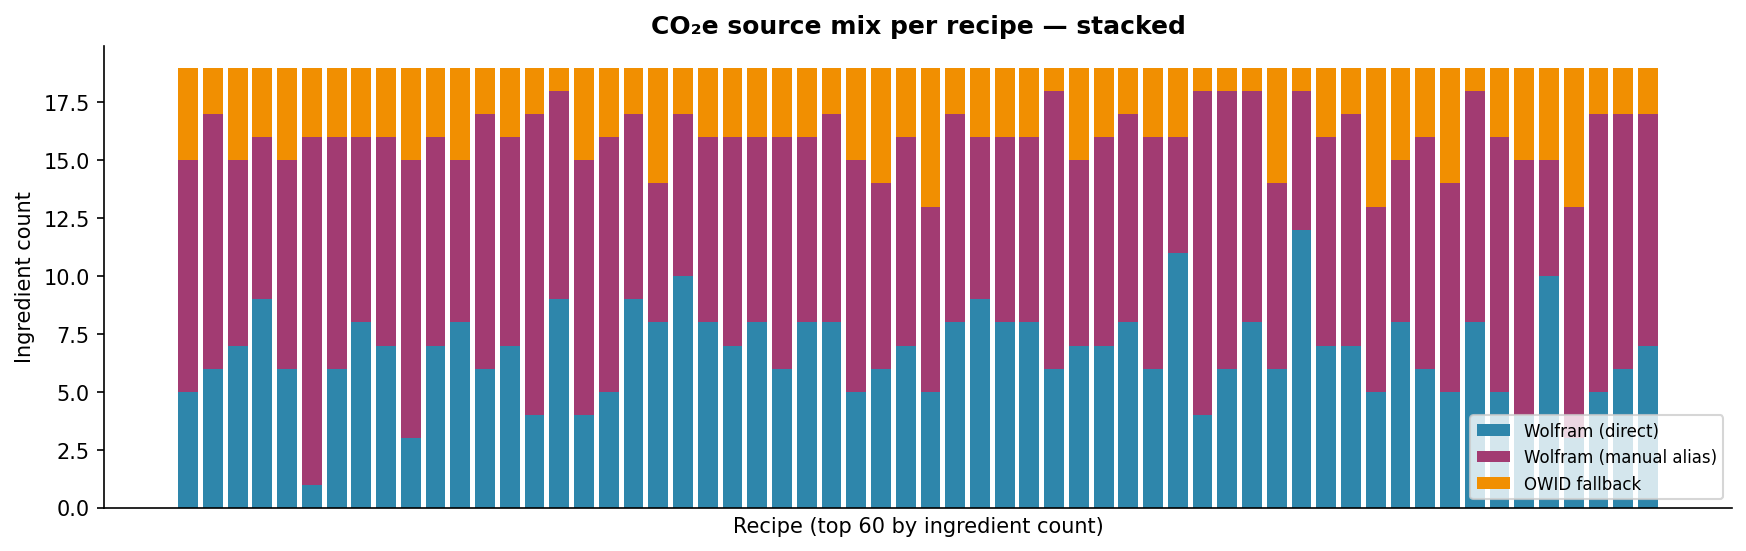

In [18]:
src_map = source_df.set_index('ingredient')['source']
ingr_df['source'] = ingr_df['ingredient_lower'].map(src_map).fillna('Unmatched')

recipe_src = (ingr_df.groupby(['recipe_id', 'source'])
              .size().unstack(fill_value=0).reset_index())
recipe_src['total'] = recipe_src.drop(columns='recipe_id').sum(axis=1)
recipe_src = recipe_src.sort_values('total', ascending=False).head(60)

source_cols = [c for c in ['Wolfram (direct)', 'Wolfram (manual alias)', 'OWID fallback', 'Unmatched']
               if c in recipe_src.columns]

fig, ax = plt.subplots(figsize=(14, 4))
bottom = [0] * len(recipe_src)
for src in source_cols:
    vals = recipe_src[src].values
    ax.bar(range(len(recipe_src)), vals, bottom=bottom, label=src,
           color=COLORS[src], edgecolor='none')
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks([])
ax.set_xlabel('Recipe (top 60 by ingredient count)')
ax.set_ylabel('Ingredient count')
ax.set_title('CO₂e source mix per recipe — stacked', fontweight='bold')
ax.legend(fontsize=8, frameon=True, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.savefig('figures/07_source_mix_per_recipe.png', bbox_inches='tight')
plt.show()


## 8 · Ingredient CO₂e — Wolfram vs OWID Values Side-by-Side

For ingredients that appear in both maps, compare the CO₂e value assigned by each source. Since Wolfram always wins, OWID values are the "road not taken" for those overlapping ingredients.

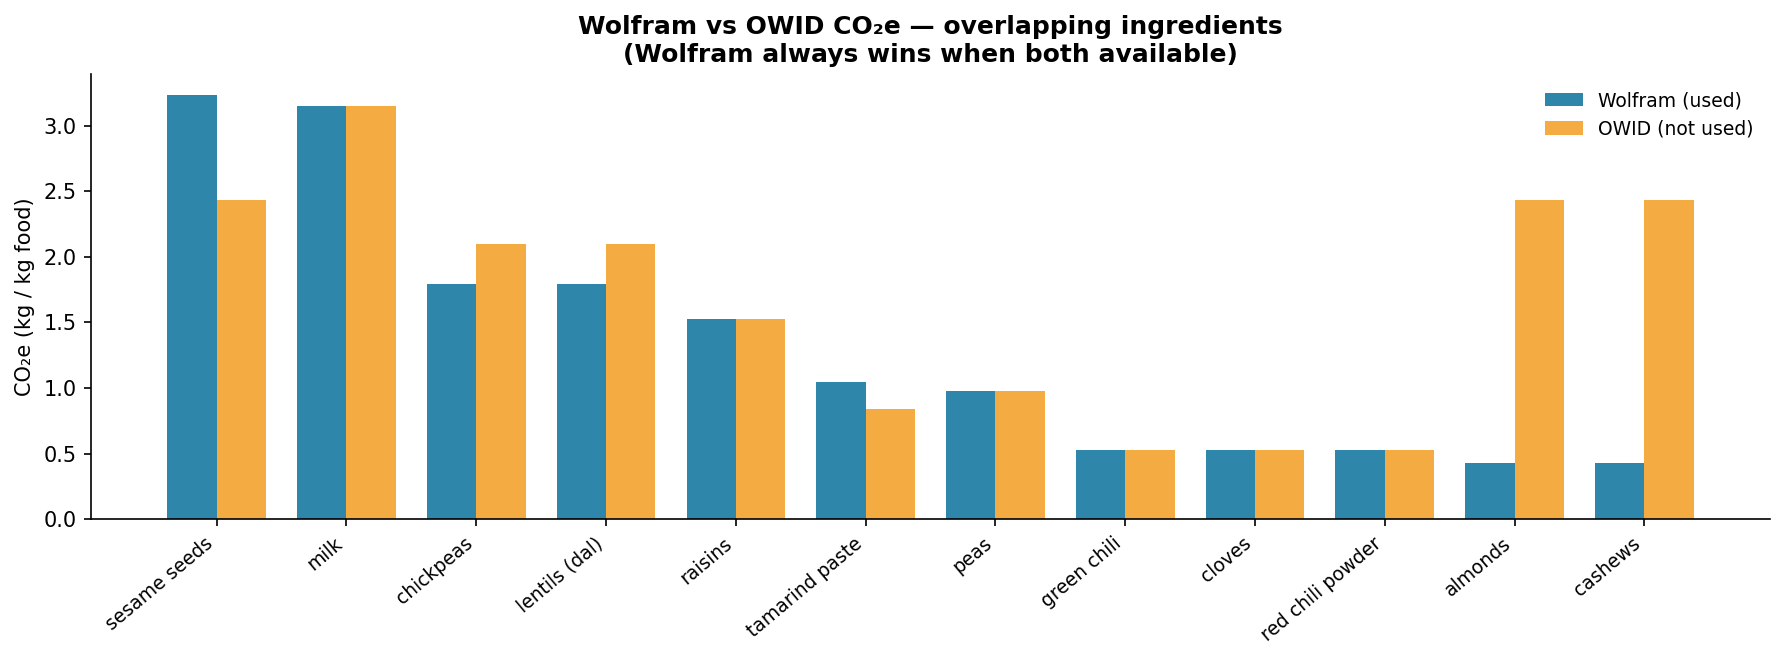

In [10]:
OWID_VALUES = {
    'cheese':21.55,'wheat & rye':1.4,'poultry meat':9.87,'onions & leeks':0.5,
    'milk':3.15,'other pulses':2.1,'peas':0.98,'potatoes':0.46,'tomatoes':1.44,
    'root vegetables':0.43,'brassicas':0.51,'nuts':2.43,'berries & grapes':1.53,
    'other vegetables':0.53,'groundnuts':2.43,'other fruit':0.84,
}

rows = []
for k in OWID_MAP:
    if k in WOLFRAM_MAP:
        wolfram_val = source_df.loc[source_df['ingredient'] == k, 'co2_kg_per_kg']
        owid_val = OWID_VALUES.get(OWID_MAP[k])
        if len(wolfram_val) and pd.notna(wolfram_val.values[0]) and owid_val:
            rows.append({'ingredient': k, 'Wolfram (used)': wolfram_val.values[0], 'OWID (not used)': owid_val})

comp_df = pd.DataFrame(rows).sort_values('Wolfram (used)', ascending=False)
x = range(len(comp_df))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar([i - w/2 for i in x], comp_df['Wolfram (used)'], width=w, label='Wolfram (used)', color='#2E86AB')
ax.bar([i + w/2 for i in x], comp_df['OWID (not used)'], width=w, label='OWID (not used)', color='#F18F01', alpha=0.75)
ax.set_xticks(list(x))
ax.set_xticklabels(comp_df['ingredient'], rotation=40, ha='right', fontsize=9)
ax.set_ylabel('CO₂e (kg / kg food)')
ax.set_title('Wolfram vs OWID CO₂e — overlapping ingredients\n(Wolfram always wins when both available)', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('figures/08_wolfram_vs_owid_comparison.png', bbox_inches='tight')
plt.show()
